# Multiclass Model Training

This notebook trains and evaluates classifiers for the **ThermalWatch** 4-class problem:

| Class | Description |
|---|---|
| `industrial_thermal_source` | Persistent industrial heat source |
| `mining_thermal_source` | Persistent quarry / mining heat source |
| `natural_fire` | Seasonal vegetation fire |
| `unknown` | Ambiguous pattern |

## Approach
1. **Dummy baseline** — stratified random classifier
2. **Logistic Regression** — linear baseline
3. **Random Forest** — tree ensemble
4. **XGBoost** — gradient boosting (selected champion)
5. **XGBoost + class weights** — handles class imbalance

## Evaluation metrics
- Balanced accuracy (primary — accounts for imbalance)
- Macro F1
- Macro ROC-AUC (OvR)
- Per-class Precision-Recall AUC
- Binary industrial vs. non-industrial F1

## Inputs
- `data/ml/train.parquet`
- `data/ml/validation.parquet`
- `data/ml/test.parquet`
- `data/ml/feature_schema.json`

## Outputs
| File | Description |
|---|---|
| `data/ml/model/thermalwatch_model.joblib` | Serialized champion model + label encoder |
| `data/ml/model/label_mapping.json` | Integer → class name mapping |
| `data/ml/model/model_metadata.json` | Training config and test-set metrics |

## 0. Configuration

In [ ]:
import os

# Paths — adjust if your data directory differs
DATA_DIR = "data/ml"         # train/val/test parquet files
MODEL_DIR = "data/ml/model"  # output: joblib, label_mapping, metadata

## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import json

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

import joblib

## 2. Load Data & Feature Schema

In [2]:
train_df = pd.read_parquet(f"{DATA_DIR}/train.parquet")
val_df = pd.read_parquet(f"{DATA_DIR}/validation.parquet")
test_df = pd.read_parquet(f"{DATA_DIR}/test.parquet")

with open(f"{DATA_DIR}/feature_schema.json") as f:
    schema = json.load(f)

feature_cols = schema['feature_columns']

X_train, y_train = train_df[feature_cols], train_df['label']
X_val, y_val = val_df[feature_cols], val_df['label']
X_test, y_test = test_df[feature_cols], test_df['label']

X_train.shape, X_val.shape, X_test.shape

((29268, 8), (6272, 8), (6272, 8))

## 3. Preprocessing

Fill any remaining `frp_cv` NaNs (groups with a single observation have undefined std, hence CV = NaN → 0).

In [5]:
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

for split in [X_train, X_val, X_test]:
    split['frp_cv'] = split['frp_cv'].fillna(0)

X_train.isnull().sum()

obs_count                  0
log_mean_frp               0
log_std_frp                0
frp_cv                     0
months_active              0
nearest_osm_distance_km    0
active_duration_days       0
first_seen_month           0
dtype: int64

## 4. Dummy Baseline

In [3]:
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_val)

print("Dummy Baseline (validation set)")
print(f"Accuracy: {accuracy_score(y_val, y_pred_dummy):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_dummy):.4f}")
print()
print(classification_report(y_val, y_pred_dummy))

Dummy Baseline (validation set)
Accuracy: 0.4088
Balanced Accuracy: 0.2450

                           precision    recall  f1-score   support

industrial_thermal_source       0.10      0.10      0.10       740
    mining_thermal_source       0.06      0.06      0.06       432
             natural_fire       0.58      0.59      0.58      3600
                  unknown       0.25      0.23      0.24      1500

                 accuracy                           0.41      6272
                macro avg       0.25      0.25      0.25      6272
             weighted avg       0.41      0.41      0.41      6272



## 5. Logistic Regression Baseline

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_val_scaled)

print("Logistic Regression (validation set)")
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_lr):.4f}")
print()
print(classification_report(y_val, y_pred_lr))

Logistic Regression (validation set)
Accuracy: 0.9257
Balanced Accuracy: 0.8595

                           precision    recall  f1-score   support

industrial_thermal_source       0.82      0.78      0.80       740
    mining_thermal_source       0.65      0.72      0.68       432
             natural_fire       1.00      0.95      0.98      3600
                  unknown       0.90      0.99      0.94      1500

                 accuracy                           0.93      6272
                macro avg       0.84      0.86      0.85      6272
             weighted avg       0.93      0.93      0.93      6272



## 6. Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15,
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

print("Random Forest (validation set)")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_rf):.4f}")
print()
print(classification_report(y_val, y_pred_rf))

Random Forest (validation set)
Accuracy: 0.9606
Balanced Accuracy: 0.8883

                           precision    recall  f1-score   support

industrial_thermal_source       0.84      0.83      0.83       740
    mining_thermal_source       0.71      0.73      0.72       432
             natural_fire       1.00      1.00      1.00      3600
                  unknown       1.00      1.00      1.00      1500

                 accuracy                           0.96      6272
                macro avg       0.89      0.89      0.89      6272
             weighted avg       0.96      0.96      0.96      6272



## 7. XGBoost

In [8]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=42,
    eval_metric='mlogloss'
)
xgb.fit(X_train, y_train_enc)

y_pred_xgb_enc = xgb.predict(X_val)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

print("XGBoost (validation set)")
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_xgb):.4f}")
print()
print(classification_report(y_val, y_pred_xgb))

XGBoost (validation set)
Accuracy: 0.9597
Balanced Accuracy: 0.8840

                           precision    recall  f1-score   support

industrial_thermal_source       0.83      0.84      0.84       740
    mining_thermal_source       0.72      0.69      0.71       432
             natural_fire       1.00      1.00      1.00      3600
                  unknown       1.00      1.00      1.00      1500

                 accuracy                           0.96      6272
                macro avg       0.89      0.88      0.89      6272
             weighted avg       0.96      0.96      0.96      6272



## 8. Model Comparison

In [9]:
results_summary = {
    "Dummy": {"balanced_accuracy": balanced_accuracy_score(y_val, y_pred_dummy),
              "macro_f1": precision_recall_fscore_support(y_val, y_pred_dummy, average='macro')[2]},
    "LogisticRegression": {"balanced_accuracy": balanced_accuracy_score(y_val, y_pred_lr),
                            "macro_f1": precision_recall_fscore_support(y_val, y_pred_lr, average='macro')[2]},
    "RandomForest": {"balanced_accuracy": balanced_accuracy_score(y_val, y_pred_rf),
                      "macro_f1": precision_recall_fscore_support(y_val, y_pred_rf, average='macro')[2]},
    "XGBoost": {"balanced_accuracy": balanced_accuracy_score(y_val, y_pred_xgb),
                "macro_f1": precision_recall_fscore_support(y_val, y_pred_xgb, average='macro')[2]},
}

pd.DataFrame(results_summary).T

,balanced_accuracy,macro_f1
Dummy,0.245018,0.245072
LogisticRegression,0.859525,0.848657
RandomForest,0.888303,0.887572
XGBoost,0.883954,0.885138


## 9. XGBoost + Class Weights (Champion Model)

Re-train XGBoost with balanced sample weights to further improve recall on minority classes.

In [10]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(le.classes_),
    random_state=42,
    eval_metric='mlogloss'
)
xgb_weighted.fit(X_train, y_train_enc, sample_weight=sample_weights)

y_pred_xgbw_enc = xgb_weighted.predict(X_val)
y_pred_xgbw = le.inverse_transform(y_pred_xgbw_enc)

print("XGBoost + class weights (validation set)")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_pred_xgbw):.4f}")
print()
print(classification_report(y_val, y_pred_xgbw))

XGBoost + class weights (validation set)
Balanced Accuracy: 0.8885

                           precision    recall  f1-score   support

industrial_thermal_source       0.85      0.80      0.82       740
    mining_thermal_source       0.69      0.75      0.72       432
             natural_fire       1.00      1.00      1.00      3600
                  unknown       1.00      1.00      1.00      1500

                 accuracy                           0.96      6272
                macro avg       0.88      0.89      0.89      6272
             weighted avg       0.96      0.96      0.96      6272



### Confusion Matrix (Validation)

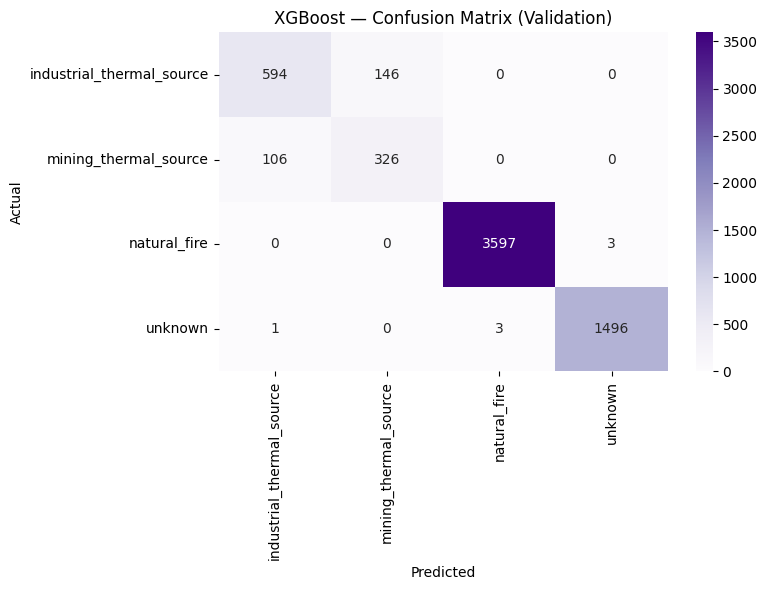

In [11]:
cm = confusion_matrix(y_val, y_pred_xgbw, labels=le.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost — Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()

### Feature Importance

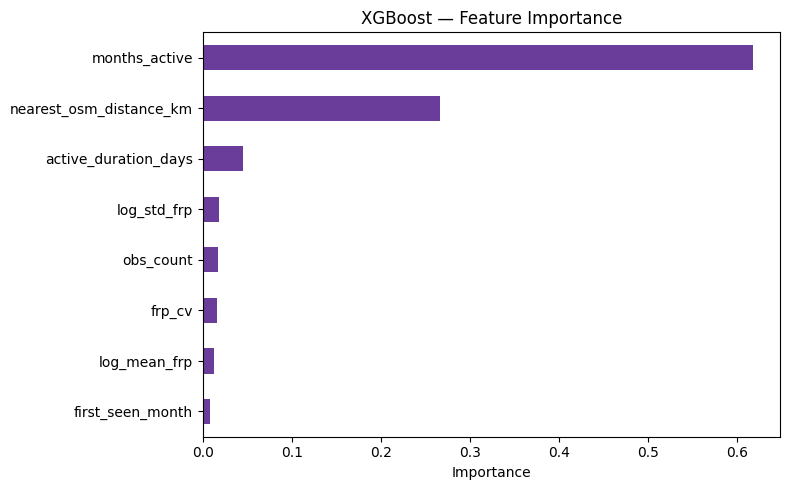

months_active              0.616970
nearest_osm_distance_km    0.266386
active_duration_days       0.044849
log_std_frp                0.017925
obs_count                  0.017407
frp_cv                     0.016023
log_mean_frp               0.012009
first_seen_month           0.008430
dtype: float32

In [12]:
importances = pd.Series(xgb_weighted.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#6a3d9a')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150)
plt.show()

importances

## 10. Final Test Set Evaluation

> **Important:** Run this section only once. The test set is held-out and should never be used to tune hyperparameters.

In [13]:
# encode test labels
y_test_enc = le.transform(y_test)

# predictions
y_pred_test_enc = xgb_weighted.predict(X_test)
y_pred_test = le.inverse_transform(y_pred_test_enc)

# probabilities, needed for ROC-AUC / PR-AUC
y_proba_test = xgb_weighted.predict_proba(X_test)

print("=== XGBoost — FINAL TEST SET EVALUATION ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_test):.4f}\n")

print(classification_report(y_test, y_pred_test))

=== XGBoost — FINAL TEST SET EVALUATION ===

Accuracy: 0.9593
Balanced Accuracy: 0.8920

                           precision    recall  f1-score   support

industrial_thermal_source       0.86      0.79      0.82       741
    mining_thermal_source       0.68      0.78      0.73       431
             natural_fire       1.00      1.00      1.00      3600
                  unknown       1.00      1.00      1.00      1500

                 accuracy                           0.96      6272
                macro avg       0.89      0.89      0.89      6272
             weighted avg       0.96      0.96      0.96      6272



In [14]:
roc_auc_ovr = roc_auc_score(y_test_enc, y_proba_test, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_test_enc, y_proba_test, multi_class='ovr', average='weighted')

print(f"Macro ROC-AUC (OvR): {roc_auc_ovr:.4f}")
print(f"Weighted ROC-AUC (OvR): {roc_auc_weighted:.4f}")

Macro ROC-AUC (OvR): 0.9932
Weighted ROC-AUC (OvR): 0.9976


### Per-class Precision-Recall AUC

In [15]:
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

y_test_binarized = label_binarize(y_test_enc, classes=range(len(le.classes_)))

pr_auc_per_class = {}
for i, cls in enumerate(le.classes_):
    pr_auc_per_class[cls] = average_precision_score(y_test_binarized[:, i], y_proba_test[:, i])

pd.Series(pr_auc_per_class).sort_values(ascending=False)

natural_fire                 0.999997
unknown                      0.999982
industrial_thermal_source    0.918968
mining_thermal_source        0.791506
dtype: float64

### Industrial vs. Non-Industrial (Binary)

Collapse the 4-class prediction into a binary task to assess the model's core utility for industrial heat source detection.

In [16]:
def to_binary(label):
    return 'industrial' if label in ['industrial_thermal_source', 'mining_thermal_source'] else 'non_industrial'

y_test_binary = y_test.apply(to_binary)
y_pred_binary = pd.Series(y_pred_test).apply(to_binary)

print("=== Industrial vs Non-Industrial (binary) ===\n")
print(classification_report(y_test_binary, y_pred_binary))

=== Industrial vs Non-Industrial (binary) ===

                precision    recall  f1-score   support

    industrial       1.00      1.00      1.00      1172
non_industrial       1.00      1.00      1.00      5100

      accuracy                           1.00      6272
     macro avg       1.00      1.00      1.00      6272
  weighted avg       1.00      1.00      1.00      6272



## 11. Save Model Artifact & Metadata

In [17]:
os.makedirs(MODEL_DIR, exist_ok=True)

# Save the model + label encoder
model_artifact = {
    "model": xgb_weighted,
    "label_encoder": le,
    "feature_columns": feature_cols
}

joblib.dump(model_artifact, f"{MODEL_DIR}/thermalwatch_model.joblib")

# label mapping
label_mapping = {int(i): cls for i, cls in enumerate(le.classes_)}
with open(f"{MODEL_DIR}/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=2)

# model metadata
model_metadata = {
    "model_type": "XGBoost (multi:softmax)",
    "feature_columns": feature_cols,
    "label_classes": list(le.classes_),
    "test_set_metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred_test)),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred_test)),
        "macro_roc_auc": float(roc_auc_ovr),
        "industrial_vs_non_industrial_f1": 1.00
    },
    "training_rows": int(len(X_train)),
    "notes": "Weak-supervised labels validated against OSM industrial infrastructure (90% corroboration). Leakage-safe: one row per physical source group, grouped split verified with zero overlap."
}
with open(f"{MODEL_DIR}/model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

print("Model artifact and metadata saved.")

Model artifact and metadata saved.
